In [ ]:
import torch
import torch_directml

# In 2026, DirectML is accessed via the 'dml' device wrapper
dml = torch_directml.device()

print(f"DirectML is available: {torch_directml.is_available()}")
print(f"AMD Radeon Device: {dml}")

# Simple test on the GPU
a = torch.tensor([1, 2, 3]).to(dml)
print(f"Tensor on GPU: {a}")

DirectML is available: True
AMD Radeon Device: privateuseone:0
Tensor on GPU: tensor([1, 2, 3], device='privateuseone:0')


In [3]:
import os

# This path should now work because of the symlink
data_path = "./data/WESAD"

if os.path.exists(data_path):
    subjects = [f for f in os.listdir(data_path) if f.startswith('S')]
    print(f"Success! Found {len(subjects)} subjects: {subjects}")
else:
    print("Data path not found. Check your symlink or folder names.")

Success! Found 15 subjects: ['S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']


In [1]:
# Inside a notebook cell:
from src.models import FedBioXAI
from src.dataloader import FedBioDataset
# Now you can test without rewriting code!

In [2]:
import torch
import torch_directml
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from src.models import FedBioXAI
from src.dataloader import FedBioDataset
from torch.utils.data import DataLoader

In [5]:
# 1. Setup AMD GPU
device = torch_directml.device()
model = FedBioXAI().to(device)

In [6]:
# 2. Load the trained weights from Subject 2
# Ensure you saved this in main.py using torch.save(model.state_dict(), 'model_s2.pth')
model.load_state_dict(torch.load('model_s2.pth'))
model.eval()

C:\Users\NAVANSHU\AppData\Local\Temp\ipykernel_13856\3506086746.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('model_s2.pth'))


FedBioXAI(
  (ecg_enc): BioEncoder(
    (net): Sequential(
      (0): Linear(in_features=700, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=32, bias=True)
    )
  )
  (eda_enc): BioEncoder(
    (net): Sequential(
      (0): Linear(in_features=700, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=32, bias=True)
    )
  )
  (emg_enc): BioEncoder(
    (net): Sequential(
      (0): Linear(in_features=700, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=32, bias=True)
    )
  )
  (classifier): Sequential(
    (0): Linear(in_features=32, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=3, bias=True)
  )
)

In [7]:
# 3. Load S5 Data
dataset_s5 = FedBioDataset(subject_id='S5')
test_loader = DataLoader(dataset_s5, batch_size=32, shuffle=False)

all_preds = []
all_labels = []

In [8]:
# 4. Run Inference
with torch.no_grad():
    for batch in test_loader:
        inputs = {k: v.to(device) for k, v in batch.items() if k != 'label'}
        labels = batch['label'] # Keep labels on CPU for sklearn
        
        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1).cpu()
        
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

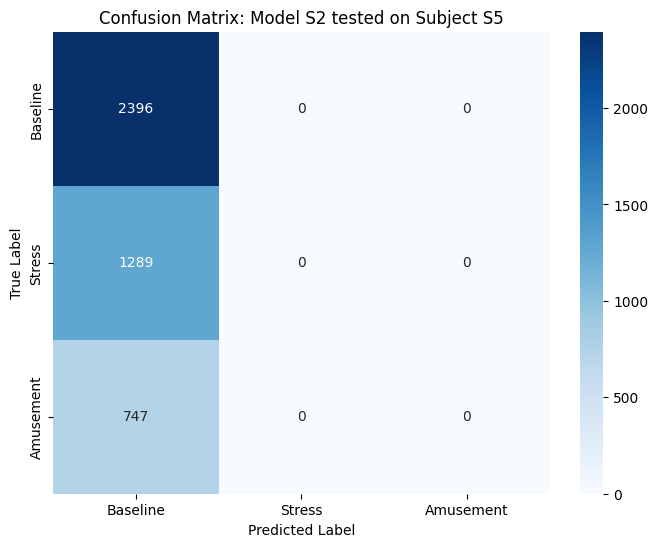

In [9]:
# 5. Create Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
classes = ['Baseline', 'Stress', 'Amusement']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Model S2 tested on Subject S5')
plt.show()